#### Set-up

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_DIR=Path("..")/'data'
train_transaction = pd.read_csv(BASE_DIR/'train_transaction.csv')
train_identity = pd.read_csv(BASE_DIR/'train_identity.csv')


In [3]:
train_transaction.shape

(590540, 394)

In [4]:
train_identity.shape

(144233, 41)

In [5]:
train_transaction['TransactionID'].isin(train_identity['TransactionID']).mean()
# this shows that 24.42% of transactions have identity data.

np.float64(0.2442391709283029)

#### Step 1: EDA on train_transaction

In [6]:
train_transaction.head()
train_transaction.info()
train_transaction.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


TransactionDT is a time delta variable and represents the number of seconds elapsed since a fixed reference start date. It does not give us the calender date and has an arbitrary start (done for provacy reasons). It is in seconds and has to be converted.

In [7]:
list(train_transaction.columns)

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

In [8]:
train_transaction.sort_values('TransactionAmt', ascending=False).head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
274339,3261339,0,6652391,31937.391,W,16075,514.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
274336,3261336,0,6652360,31937.391,W,16075,514.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
296021,3283021,0,7320188,6450.970,W,16661,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
248413,3235413,0,5926506,6085.230,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
384603,3371603,0,9648912,5543.230,W,11106,100.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
train_transaction.sort_values('TransactionAmt', ascending=True).head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
374299,3361299,0,9324090,0.251,C,4480,366.0,162.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367961,3354961,0,9147032,0.272,C,1903,555.0,146.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205872,3192872,1,4734702,0.292,C,15885,545.0,185.0,visa,138.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205865,3192865,1,4734545,0.292,C,15885,545.0,185.0,visa,138.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29976,3016976,1,757661,0.292,C,15885,545.0,185.0,visa,138.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### TransactionAmt

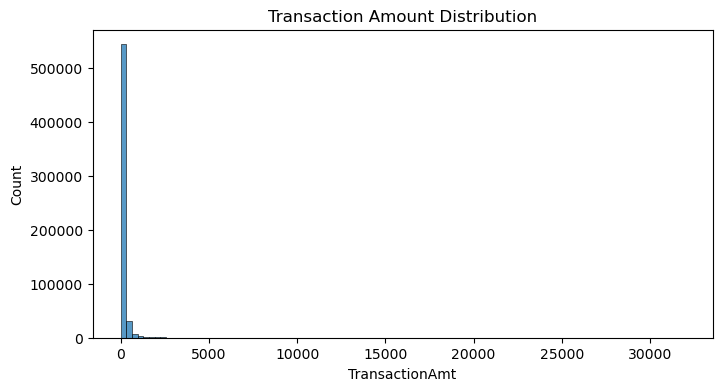

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(train_transaction['TransactionAmt'], bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

In [11]:
train_transaction['TransactionAmt'].skew()

np.float64(14.374489573829827)

A skewness of 14.37 indicates that the distribution of TransactionAmt is extremely positively skewed, with very large valued outliers.

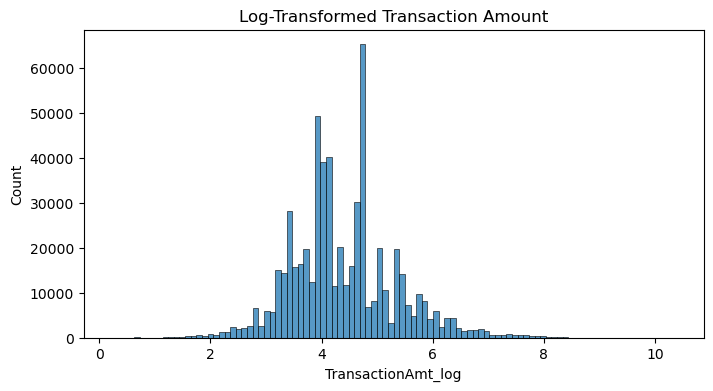

In [12]:
# Log-transform TransactionAmt to better see the distribution.
# Compress large values and stretch smaller ones.
train_transaction['TransactionAmt_log'] = np.log1p(train_transaction['TransactionAmt'])

plt.figure(figsize=(8,4))
sns.histplot(train_transaction['TransactionAmt_log'], bins=100)
plt.title("Log-Transformed Transaction Amount")
plt.show()

In [13]:
train_transaction['TransactionAmt_log'].skew()

np.float64(0.48829099714653196)

The TransactionAmt variable was extremely right-skewed (skew = 14.37). After applying a log transformation, the distribution became nearly symmetric (skew = 0.49).

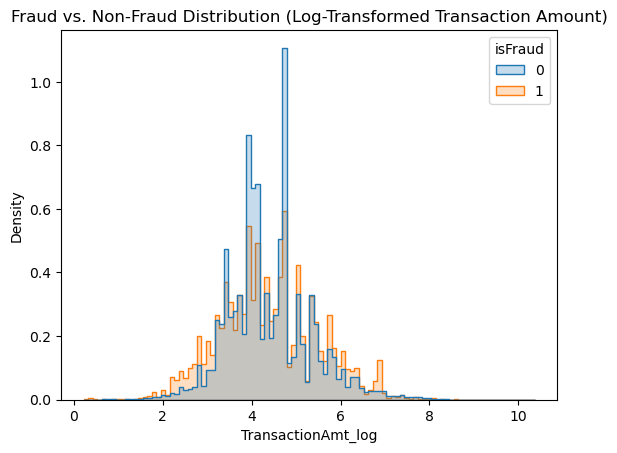

In [14]:
sns.histplot(
    data=train_transaction,
    x='TransactionAmt_log',
    hue='isFraud',
    bins=100,
    element='step',
    stat='density', #Normalize the counts (unequal numbers of observations)
    common_norm=False
)
plt.title("Fraud vs. Non-Fraud Distribution (Log-Transformed Transaction Amount)")
plt.show()

The log-transformed transaction amounts show that fraudulent transactions are more concentrated in very low and unusual high ranges, whereas most legitimate transactions cluster in mid-range amounts. While the log transformation reduces skewness and allows better visualization, there is still considerable overlap between fraud and non-fraud transactions. This suggests that TransactionAmt is moderately predictive but not sufficient for reliable fraud detection on its own.

#### isFraud

In [15]:
# Calculate the frequency distribution
train_transaction['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [16]:
train_transaction['isFraud'].skew()

np.float64(5.061222731104751)

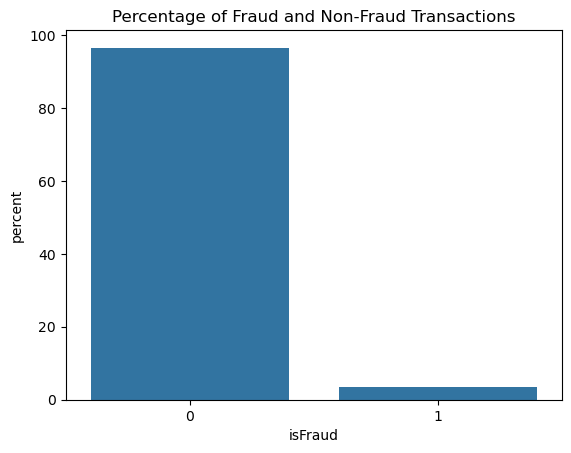

In [17]:
sns.countplot(
    data=train_transaction,
    x='isFraud',
    stat='percent'
)
plt.title("Percentage of Fraud and Non-Fraud Transactions")
plt.show()

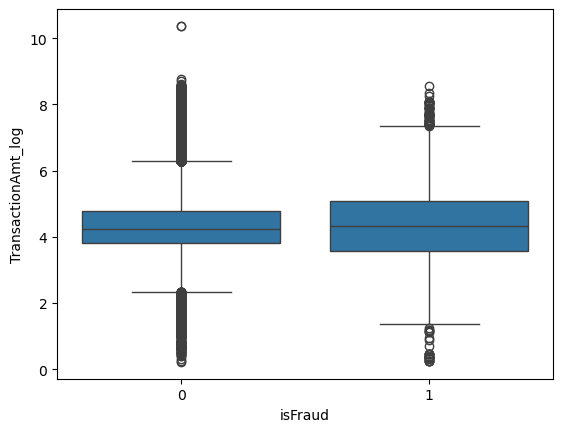

In [18]:
sns.boxplot(data=train_transaction,
            x='isFraud', 
            y='TransactionAmt_log'
            )
plt.show()

In [19]:
train_transaction['Amt_bin'] = pd.qcut(train_transaction['TransactionAmt'], 
                        q=10, # 10 bins (deciles)
                        duplicates='drop')

fraud_by_bin = (
    train_transaction
    .groupby('Amt_bin', observed=True)['isFraud']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'fraud_rate'})
)

fraud_by_bin

,count,fraud_rate
Amt_bin,,
"(0.25, 25.95]",59511,0.055889
"(25.95, 35.95]",61650,0.032052
"(35.95, 49.0]",65116,0.032250
"(49.0, 57.95]",59647,0.019431
"(57.95, 68.769]",49346,0.028513
"(68.769, 100.0]",73349,0.036170
"(100.0, 117.0]",72079,0.019742
"(117.0, 159.95]",32399,0.043026
"(159.95, 275.293]",58390,0.038037


#### Anonymous Values
Since this dataset is anonymized, there is no official mapping for the features. But there are strategies to infer likely meanings and their relevance.

In [20]:
c_cols = [col for col in train_transaction.columns if col.startswith('C')]
d_cols = [col for col in train_transaction.columns if col.startswith('D')]
m_cols = [col for col in train_transaction.columns if col.startswith('M')]
v_cols = [col for col in train_transaction.columns if col.startswith('V')]

In [21]:
train_transaction[c_cols].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215
std,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000
75%,3.000000,3.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,12.000000,2.000000
max,4685.000000,5691.000000,26.000000,2253.000000,349.000000,2253.000000,2255.000000,3331.000000,210.000000,3257.000000,3188.000000,3188.000000,2918.000000,1429.000000


In [22]:
train_transaction[c_cols].skew().sort_values(ascending=True)

C9      5.693750
C5      5.793670
C13     8.986417
C14    16.534887
C6     19.766863
C4     22.077659
C11    22.356975
C2     23.677433
C1     23.957960
C10    25.220514
C8     26.083382
C7     27.194050
C12    27.415129
C3     88.949746
dtype: float64

In [23]:
train_transaction.groupby('isFraud')[c_cols].mean()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
isFraud,,,,,,,,,,,,,,
0,13.314952,14.173283,0.005840,3.693878,5.722537,8.786377,2.517484,4.560881,4.580904,4.723526,9.747825,3.549703,32.814474,8.220491
1,35.535740,45.509413,0.000242,15.077336,1.406717,16.923148,11.977157,21.242608,1.703964,19.493926,23.857475,18.597541,24.967768,10.356047


In [24]:
train_transaction[d_cols].describe()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
count,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,73187.000000,38917.000000,74926.000000,74926.000000,514518.000000,311253.000000,64717.000000,61952.000000,62187.000000,501427.000000
mean,94.347568,169.563231,28.343348,140.002441,42.335965,69.805717,41.638950,146.058108,0.561057,123.982137,146.621465,54.037533,17.901295,57.724444,163.744579
std,157.660387,177.315865,62.384721,191.096774,89.000144,143.669253,99.743264,231.663840,0.316880,182.615225,186.042622,124.274558,67.614425,136.312450,202.726660
min,0.000000,0.000000,0.000000,-122.000000,0.000000,-83.000000,0.000000,0.000000,0.000000,0.000000,-53.000000,-83.000000,0.000000,-193.000000,-83.000000
25%,0.000000,26.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.958333,0.208333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,97.000000,8.000000,26.000000,10.000000,0.000000,0.000000,37.875000,0.666666,15.000000,43.000000,0.000000,0.000000,0.000000,52.000000
75%,122.000000,276.000000,27.000000,253.000000,32.000000,40.000000,17.000000,187.958328,0.833333,197.000000,274.000000,13.000000,0.000000,2.000000,314.000000
max,640.000000,640.000000,819.000000,869.000000,819.000000,873.000000,843.000000,1707.791626,0.958333,876.000000,670.000000,648.000000,847.000000,878.000000,879.000000


In [25]:
train_transaction.groupby('isFraud')[d_cols].mean()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
isFraud,,,,,,,,,,,,,,,
0,96.364705,171.956223,28.845357,142.432339,43.491155,72.629046,46.943007,157.343727,0.565846,126.396130,147.808201,55.345787,19.316574,58.152163,166.633142
1,38.711306,77.774206,11.744880,72.102904,13.687776,45.856439,11.292228,49.309191,0.520000,52.363653,87.314445,44.202553,6.492321,54.464578,78.245805


In [26]:
train_transaction[m_cols].describe()

,M1,M2,M3,M4,M5,M6,M7,M8,M9
count,319440,319440,319440,309096,240058,421180,244275,244288,244288
unique,2,2,2,3,2,2,2,2,2
top,T,T,T,M0,F,F,F,F,T
freq,319415,285468,251731,196405,132491,227856,211374,155251,205656


#### Correlation Matrix

In [27]:
isNumeric = train_transaction.select_dtypes(include=['int64', 'float64']) # Avoids strings
corrMatrix = isNumeric.corr()
topCorr = (
    corrMatrix['isFraud'] # Get the features correlated with isFraud
    .abs() # Absolute strength
    .sort_values(ascending=False)
    .head(21) # 20 + isFraud itself
)

topCorr

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
V52        0.239469
Name: isFraud, dtype: float64

In [28]:
# Remove 'isFraud'
topFeatures = topCorr.index[1:]

In [29]:
topMatrix = isNumeric[topFeatures.tolist() + ['isFraud']].corr()

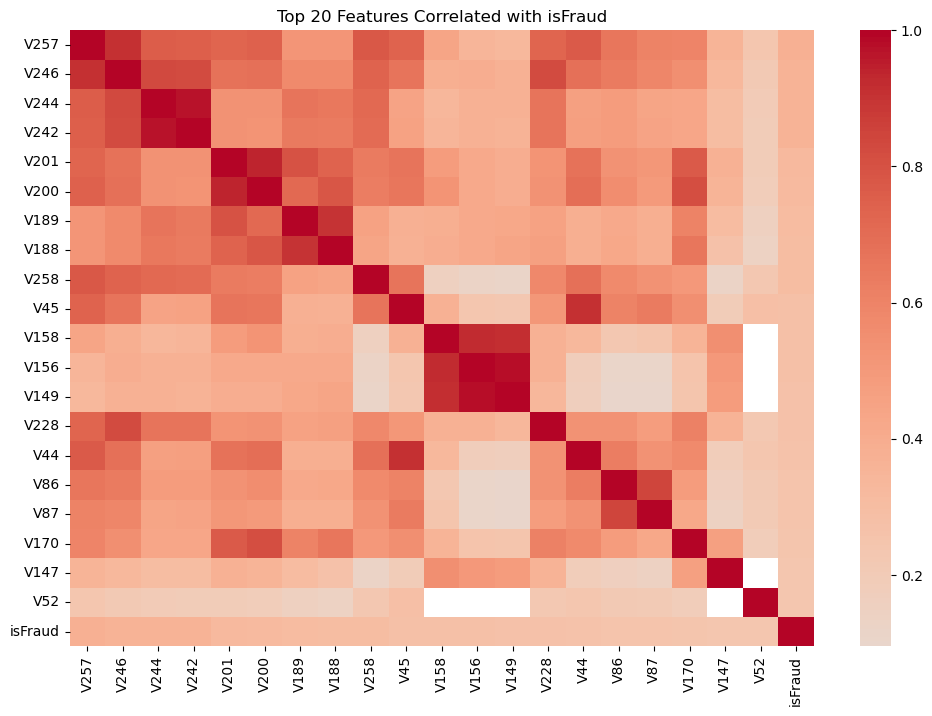

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(topMatrix,
            annot=False,
            cmap='coolwarm',
            center=0)

plt.title("Top 20 Features Correlated with isFraud")
plt.show()

#### PCA

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

v_cols = [col for col in train_transaction.columns if col.startswith('V')]

# Standardize first
scaler = StandardScaler()
V_scaled = scaler.fit_transform(train_transaction[v_cols].fillna(0))

pca = PCA()
pca.fit(V_scaled) # Fit PCA

#explained_variance = pca.explained_variance_ratio_

# After fitting:
pca = PCA(n_components=2)
V_pca = pca.fit_transform(V_scaled)

train_transaction_pca = pd.DataFrame(V_pca, columns=['PC1','PC2'])
train_transaction_pca['isFraud'] = train_transaction['isFraud'].values

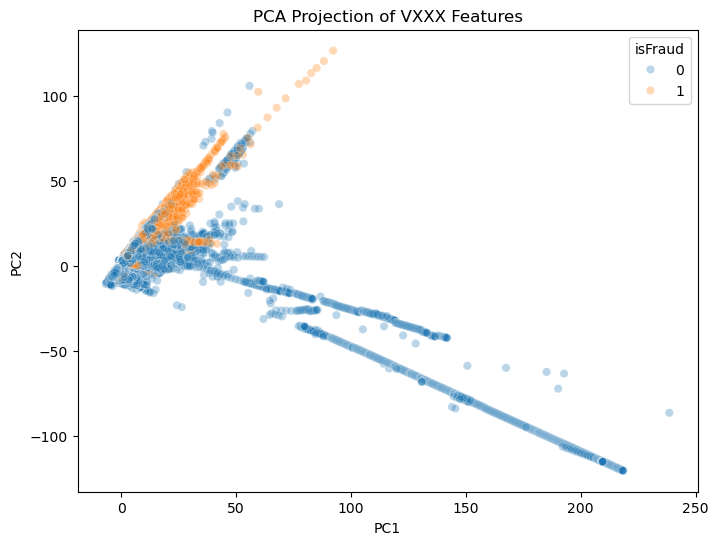

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=train_transaction_pca,
                x='PC1',
                y='PC2',
                hue='isFraud',
                alpha=0.3)

plt.title("PCA Projection of VXXX Features")
plt.show()

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = train_transaction[v_cols]
y = train_transaction['isFraud']
X = X.fillna(-999)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)

rf.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
from sklearn.metrics import roc_auc_score

y_pred_proba = rf.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_pred_proba)

0.7948181582687126

In [67]:
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score, precision_score

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96    113975
           1       0.22      0.39      0.28      4133

    accuracy                           0.93    118108
   macro avg       0.60      0.67      0.62    118108
weighted avg       0.95      0.93      0.94    118108



#### Misc. Visualizations

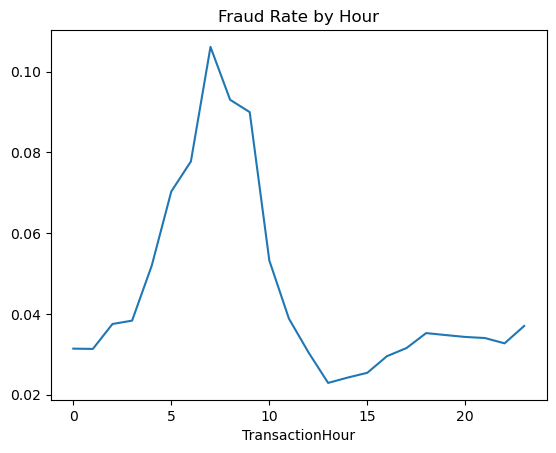

In [33]:
# Feature engineering
train_transaction['TransactionHour'] = (train_transaction['TransactionDT'] // 3600)%24
train_transaction['TransactionDay'] = (train_transaction['TransactionDT'] // (3600*24))

hour_fraud = train_transaction.groupby('TransactionHour')['isFraud'].mean()

hour_fraud.plot()
plt.title("Fraud Rate by Hour")
plt.show()

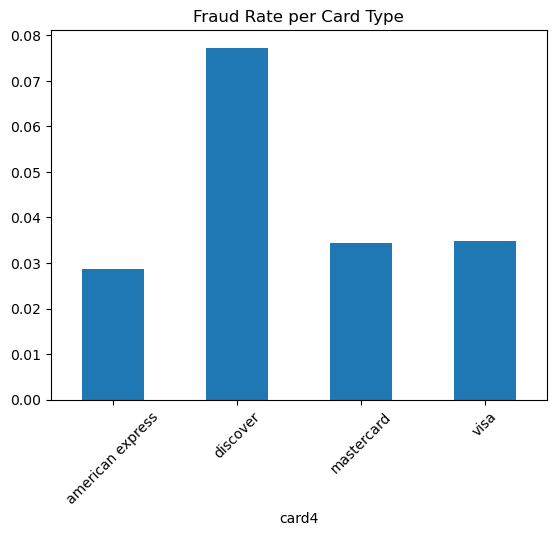

In [34]:
fraud_rate = train_transaction.groupby('card4')['isFraud'].mean()
fraud_rate.plot(kind='bar', rot=45)
plt.title("Fraud Rate per Card Type")
plt.show()

In [35]:
train_transaction.groupby('card1')['TransactionAmt'].mean()

card1
1000      23.443000
1001      79.666667
1004     136.400000
1005      50.000000
1006     133.333333
            ...    
18390     56.806406
18391    171.000000
18393    321.816667
18395     71.685455
18396    100.000000
Name: TransactionAmt, Length: 13553, dtype: float64

In [36]:
numeric_cols = train_transaction.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('isFraud')

fraud_means = train_transaction.groupby('isFraud')[numeric_cols].mean().T
fraud_means['difference'] = fraud_means[1] - fraud_means[0]
fraud_means['difference'].abs().sort_values(ascending=False).head(20)

TransactionDT    329241.956952
V160              42928.002430
TransactionID     13141.986989
V159               2537.625309
V165               2048.615360
V332               1267.664359
V333                928.550611
V164                804.684780
V203                672.952490
V331                660.940640
V212                587.234853
V204                465.121027
V213                417.755964
card1               363.810216
V202                312.928532
V211                312.615337
V150                257.194054
V166                177.551311
V307                142.173490
V317                108.513148
Name: difference, dtype: float64

#### Step 2: EDA on train_identity

In [37]:
train_identity.head()
train_identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [38]:
train_identity.isnull().mean().sort_values(ascending=False)

id_24            0.967088
id_25            0.964419
id_07            0.964259
id_08            0.964259
id_21            0.964231
id_26            0.964204
id_23            0.964162
id_27            0.964162
id_22            0.964162
id_18            0.687221
id_03            0.540161
id_04            0.540161
id_33            0.491871
id_09            0.480521
id_10            0.480521
id_30            0.462224
id_32            0.462079
id_34            0.460560
id_14            0.445037
DeviceInfo       0.177262
id_13            0.117262
id_16            0.103257
id_06            0.051084
id_05            0.051084
id_20            0.034472
id_19            0.034077
id_17            0.033723
id_31            0.027393
DeviceType       0.023732
id_02            0.023303
id_28            0.022568
id_29            0.022568
id_11            0.022568
id_15            0.022519
id_35            0.022519
id_36            0.022519
id_37            0.022519
id_38            0.022519
id_01       

In [39]:
train_identity['DeviceType'].value_counts()

DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64

In [40]:
train_identity['DeviceInfo'].value_counts().head()

DeviceInfo
Windows        47722
iOS Device     19782
MacOS          12573
Trident/7.0     7440
rv:11.0         1901
Name: count, dtype: int64

#### Step 3: Looking at IdentityID

In [41]:
identity_ids = set(train_identity['TransactionID'])
train_transaction['hasIdentity'] = train_transaction['TransactionID'].isin(identity_ids)
train_transaction['hasIdentity'].mean()

np.float64(0.2442391709283029)

In [42]:
train_transaction.groupby('hasIdentity')['isFraud'].mean()

hasIdentity
False    0.020939
True     0.078470
Name: isFraud, dtype: float64